In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import colormaps as cm

import matplotlib.pyplot as plt
from matplotlib import colormaps as mcm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FuncAnimation, FFMpegWriter

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

from IPython.display import HTML

In [2]:
def load_inferences(config):
    """Loads inferences based on the model's configuration.
    Inputs:
        config (dict): the model config
        
    Outputs:
        ds (xr.Dataset): the requested dataset 
    """
    
    # location
    inf_dir = os.path.join(SCRATCH_DIR, config["model_type"],
                           config["run"], f"inference_{config['expt']}",
                           "validation")

    if os.path.isdir(inf_dir):
        predictions = xr.open_zarr(f"{inf_dir}/graphufs.{config['duration']}.zarr")
        targets = xr.open_zarr(f"{inf_dir}/replay.{config['duration']}.zarr")
        return predictions, targets
        
    else:
        raise KeyError(f"{inf_dir} does not exist. Aborting...")

In [3]:
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
model_config = {
    "name": "ocn-only-24h-Maha",
    "type": "emulator",
    "model_type": "ocn-only",
    "run": "R8",
    "expt": "T2M",
    "pred_prefix": "graphufs",
    "timestep": "24h",
    "duration": "960h",
    "description": "24hour-maha"
}
var_config = {
    "variable": "temp",    # variable name
    "vcoord": "z_l",       # vertical coordianate name
    "ivert": 0,            # index of the vertical level
    "units": "degC",       # units of the variable
    "es_comp": "ocn",      # earth system component
}

In [4]:
colormaps_var = {
    "SSH": "gist_ncar",
    "SSHA": cm.BlueYellowRed,
    "SST": "jet",
    "SSTA": cm.GHRSST_anomaly,
}

In [5]:
predictions, targets = load_inferences(model_config)

In [6]:
predictions

<xarray.Dataset> Size: 167GB
Dimensions:    (time: 489, lead_time: 40, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 1 days 2 days ... 40 days
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-09-03
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 6GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    so         (time, lead_time, z_l, lat, lon) float32 40GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    temp       (time, lead_time, z_l, lat, lon) float32 40GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    uo         (time, lead_time, z_l, lat, lon) float32 40GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    vo         (time, lead_time, z_l, lat, lon) float32 40GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>

In [7]:
targets

<xarray.Dataset> Size: 329GB
Dimensions:    (time: 489, lead_time: 40, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 1 days 2 days ... 40 days
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-09-03
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 6GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    so         (time, z_l, lead_time, lat, lon) float64 81GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    temp       (time, z_l, lead_time, lat, lon) float64 81GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    uo         (time, z_l, lead_time, lat, lon) float64 81GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    vo         (time, z_l, lead_time, lat, lon) float64 81GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>

In [8]:
# Open the atm replay zarr-store
atm = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/03h-freq/zarr/fv3.zarr",
    storage_options={"token": "anon"},
)
atm

<xarray.Dataset> Size: 60TB
Dimensions:        (time: 87020, grid_yt: 192, grid_xt: 384, pfull: 127)
Coordinates:
    cftime         (time) object 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
    ftime          (time) timedelta64[ns] 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
  * grid_xt        (grid_xt) float64 3kB 0.0 0.9375 1.875 ... 357.2 358.1 359.1
  * grid_yt        (grid_yt) float64 2kB 89.82 88.89 87.95 ... -88.18 -89.12
  * pfull          (pfull) float32 508B 0.01278 0.02033 0.03177 ... 996.2 998.8
  * time           (time) datetime64[ns] 696kB 1993-12-31T18:00:00 ... 2023-1...
Data variables: (12/183)
    acond          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    albdo_ave      (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    ...             ...
    xtts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xu             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xv             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xz             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xzts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    zc             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
Attributes:
    abstract:         The NOAA Unified Forecast System (UFS) / Global Ensembl...
    acknowledgement:  To provide appropriate attribution under this license, ...
    description:      This zarr store is a subset of the original GEFSv13 UFS...
    license:          The Global Ensemble Forecast System version 13 (GEFSv13...

In [9]:
# Open the existing ocean zarr-store
ocn = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/06h-freq/zarr/mom6.zarr",
    storage_options={"token": "anon"},
)
ocn

<xarray.Dataset> Size: 5TB
Dimensions:       (time: 43826, lat: 192, lon: 384, zl: 75, z_l: 75)
Coordinates:
    cftime        (time) object 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
    ftime         (time) timedelta64[ns] 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
  * lat           (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lon           (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time          (time) datetime64[ns] 351kB 1993-12-31T18:00:00 ... 2023-12-31
  * z_l           (z_l) float64 600B 0.5154 1.571 2.687 ... 5.698e+03 5.902e+03
  * zl            (zl) float64 600B 1.0 3.0 5.0 ... 3.591e+03 5.111e+03
Data variables: (12/21)
    Heat_PmE      (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LwLatSens     (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SSH           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    depth         (lat, lon) float32 295kB dask.array<chunksize=(96, 384), meta=np.ndarray>
    ...            ...
    so            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    taux          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    tauy          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    temp          (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    uo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    vo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>

## Compute Climatology and check anomaly

In [10]:
# Climatology for intended variable and the level for the training period
quantity = ocn[var_config["variable"]]
if var_config["vcoord"] in quantity.dims:
    quantity = quantity.isel({var_config["vcoord"]: var_config["ivert"]})

climatology = quantity.sel(time=slice("1993-12-31", "2019-12-31")).groupby("time.month").mean("time").load()

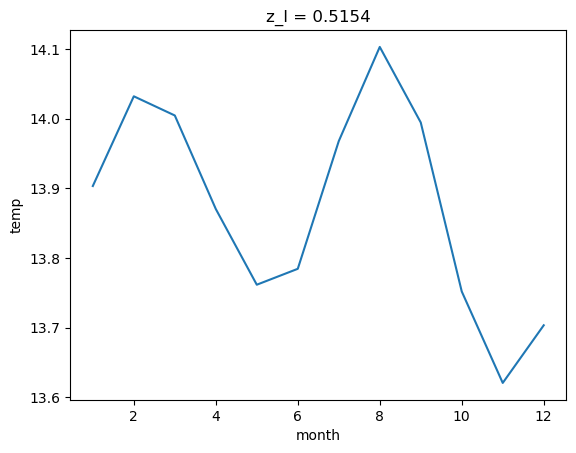

In [11]:
climatology.mean(("lat","lon")).plot()
plt.show()

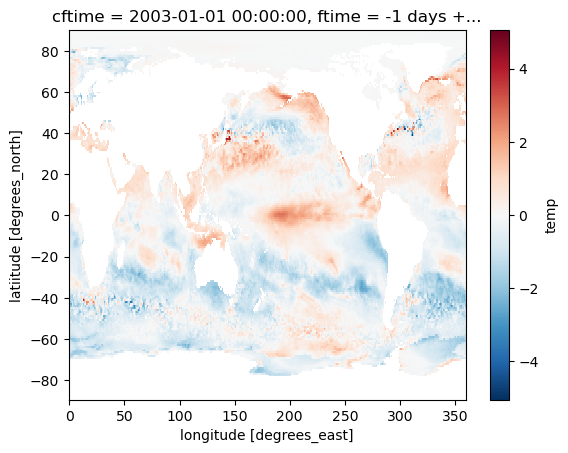

In [12]:
# Compute Anomaly using the above climatology
anomaly = quantity.unify_chunks().sel(time=slice("2003-01-01", "2003-02-28")).groupby("time.month") - climatology
anomaly.isel(time=0).plot()
plt.show()

# Plot using Orthographic Projection and Contourf

In [13]:
plot_config = {
    "itime": 0,            # initialization time
    "truth": "Replay",     # reference truth
    "plot_anomaly": True,
    "lat_max_from_equator_for_anim": 10,
    "nlevels": 100, # number of contour levels
    "save_plot": True,
    # lead time to plot
    "lead_start": 0,
    "lead_end": 5,  # this must be changed for different emulators
    # initial face of the globe
    "central_lat_init": 10,
    "central_lon_init": -50,
    # colorbar/colormap related
    "vmin_cbar": -5,
    "vmax_cbar": 5,
    "cmap": cm.GHRSST_anomaly, #SSHA: cm.BlueYellowRed  # SSH:cm.balance, SST_anomaly:cm.GHRSST_anomaly
    "masked_array": True, # true for masked arrays like those for ocn, land, ice
}

Saving animation to figures/temp_anomaly_predictions_targets_z_l-0.52m_ocn-only-24h-Maha_6months_lead.mp4...


MovieWriter stderr:
[in#0/rawvideo @ 0x55e97b11a480] Error during demuxing: Immediate exit requested


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x7f64f134cae0> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



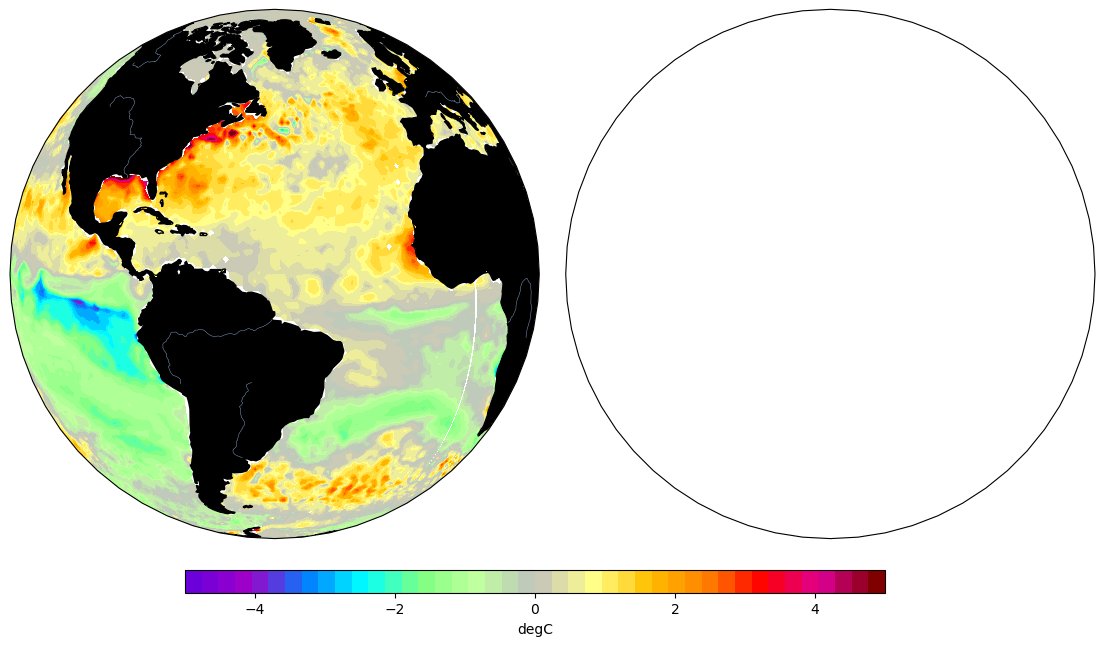

In [14]:
# ==========================================
# DATA PREPARATION
# ==========================================
# Construct common selection dictionary
sel_dict = {
    "time": plot_config["itime"],
    "lead_time": slice(plot_config["lead_start"], plot_config["lead_end"])
}

# Add vertical selection if 3D variable
is_3d = var_config["vcoord"] in predictions[var_config["variable"]].coords
if is_3d:
    sel_dict[var_config["vcoord"]] = var_config["ivert"]

# Select Data
target = targets[var_config["variable"]].isel(sel_dict)
prediction = predictions[var_config["variable"]].isel(sel_dict)

# Apply Masks
if plot_config["masked_array"]:
    mask = None
    if is_3d and var_config["vcoord"] == "z_l":
        # Ocean Mask (3D)
        mask_da = targets.so.isel({"time": plot_config["itime"], "z_l": var_config["ivert"]})
        mask = xr.where(mask_da == 0, 0, 1)
    elif var_config["variable"].lower() == "ssh":
        # SSH Mask (2D)
        mask = 1 - np.isnan(ocn.SSH.isel(time=0))
    
    if mask is not None:
        target = target.where(mask)
        prediction = prediction.where(mask)

# Compute Anomaly
if plot_config["plot_anomaly"] and climatology.any():
    forecast_time = prediction["time"] + prediction["lead_time"]
    
    # Assign coords for grouping
    prediction = prediction.assign_coords(forecast_time=("lead_time", forecast_time.values))
    target = target.assign_coords(forecast_time=("lead_time", forecast_time.values))
    
    prediction = prediction.groupby("forecast_time.month") - climatology
    target = target.groupby("forecast_time.month") - climatology

# Extract Grid info once
lons = prediction["lon"]
lats = prediction["lat"]
times = prediction["lead_time"]
lon2d, lat2d = np.meshgrid(lons, lats)

# ==========================================
# PLOTTING & ANIMATION SETUP
# ==========================================

def plot_globe_panel(ax, data, title, proj_obj, levels, cmap, vmin, vmax):
    """Helper to handle plotting logic for left/right panels."""
    ax.projection = proj_obj
    ax.set_global()
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='black')
    ax.add_feature(cfeature.RIVERS, linewidth=0.3)
    
    # Plot data
    cf = ax.contourf(
        lon2d, lat2d, data, 
        levels, 
        transform=ccrs.PlateCarree(), 
        cmap=cmap, 
        vmin=vmin, 
        vmax=vmax, 
        extend='both'
    )
    ax.set_title(title, fontsize=12)
    return cf

# Initialize Figure
fig, axs = plt.subplots(1, 2, figsize=(14, 7.5),
                        subplot_kw={'projection': ccrs.Orthographic(
                        central_longitude=plot_config["central_lon_init"],
                        central_latitude=plot_config["central_lat_init"]
                        )})

# Setup Colorbar (Do this once, outside the loop)
norm = Normalize(vmin=plot_config["vmin_cbar"], vmax=plot_config["vmax_cbar"])
sm = ScalarMappable(norm=norm, cmap=plot_config["cmap"])
sm.set_array([]) 

cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{var_config['units']}")
cbar.ax.tick_params(labelsize=10)

def update(frame):
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    
    # Calculate Rotation
    central_lon = (plot_config["central_lon_init"] - frame * 2) % 360
    central_lat = plot_config["central_lat_init"]
    
    # Create the projection object for this frame
    current_proj = ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)

    # Prepare data snapshots
    data_target = target.isel(lead_time=frame).squeeze()
    data_pred = prediction.isel(lead_time=frame).squeeze()

    # Clear and Redraw Left (Truth)
    axs[0].clear()
    plot_globe_panel(
        axs[0], data_target, plot_config["truth"], current_proj,
        plot_config["nlevels"], plot_config["cmap"], 
        plot_config["vmin_cbar"], plot_config["vmax_cbar"]
    )

    # Clear and Redraw Right (Prediction)
    axs[1].clear()
    plot_globe_panel(
        axs[1], data_pred, model_config["name"], current_proj,
        plot_config["nlevels"], plot_config["cmap"], 
        plot_config["vmin_cbar"], plot_config["vmax_cbar"]
    )

    # Update Super Title
    leadtime = pd.to_timedelta(times[frame].values, unit="D")
    print(f"Processing frame {frame}: lead time = {leadtime}")
    
    main_title = f"{var_config['variable']} anomaly, lead time = {leadtime}"
    if is_3d:
        depth_val = prediction[var_config['vcoord']].values.item() if prediction[var_config['vcoord']].size == 1 else prediction[var_config['vcoord']][0].values
        main_title += f", {var_config['vcoord']} = {depth_val:.2f}m"
    
    plt.suptitle(main_title)
    return []

# ==========================================
# EXECUTION
# ==========================================
ani = FuncAnimation(fig, update, frames=len(times), interval=500, blit=False)

# Construct Filename
f_type = "anomaly_predictions_targets" if plot_config["plot_anomaly"] else "predictions_targets"

if is_3d:
    depth_val = prediction[var_config['vcoord']].values[0] if hasattr(prediction[var_config['vcoord']].values, '__iter__') else prediction[var_config['vcoord']].values
    fname_suffix = f"{var_config['vcoord']}-{depth_val:.2f}m_{model_config['name']}_6months_lead"
else:
    fname_suffix = f"{model_config['name']}_{model_config['run']}_{model_config['expt']}"

fname = f"{var_config['variable']}_{f_type}_{fname_suffix}.mp4"

# Save or not
if plot_config["save_plot"]:
    print(f"Saving animation to figures/{fname}...")
    ani.save(f"figures/{fname}", writer='ffmpeg', fps=8, dpi=200)
else:
    HTML(ani.to_jshtml())
    plt.show()

## Animate using the Robinson projection, not Orthographic

In [17]:
plot_config = {
    "itime": 0,
    "truth": "Replay",
    "plot_anomaly": True,
    "save_plot": True,
    "lead_start": 0,
    "lead_end": 40,
    # Robinson is often best centered at 180 (Pacific View) or 0 (Atlantic View)
    "central_lon_init": 180, 
    "vmin_cbar": -5,
    "vmax_cbar": 5,
    "cmap": colormaps_var["SSTA"], 
    "masked_array": True,
}

Saving animation to figures/temp_anomaly_z_l-0.52m_ocn-only-24h-Maha_robinson.mp4...
Processing frame 0: lead time = 1 days 00:00:00
Processing frame 0: lead time = 1 days 00:00:00
Processing frame 1: lead time = 2 days 00:00:00
Processing frame 2: lead time = 3 days 00:00:00
Processing frame 3: lead time = 4 days 00:00:00
Processing frame 4: lead time = 5 days 00:00:00
Processing frame 5: lead time = 6 days 00:00:00
Processing frame 6: lead time = 7 days 00:00:00
Processing frame 7: lead time = 8 days 00:00:00
Processing frame 8: lead time = 9 days 00:00:00
Processing frame 9: lead time = 10 days 00:00:00
Processing frame 10: lead time = 11 days 00:00:00
Processing frame 11: lead time = 12 days 00:00:00
Processing frame 12: lead time = 13 days 00:00:00
Processing frame 13: lead time = 14 days 00:00:00
Processing frame 14: lead time = 15 days 00:00:00
Processing frame 15: lead time = 16 days 00:00:00
Processing frame 16: lead time = 17 days 00:00:00
Processing frame 17: lead time = 18 

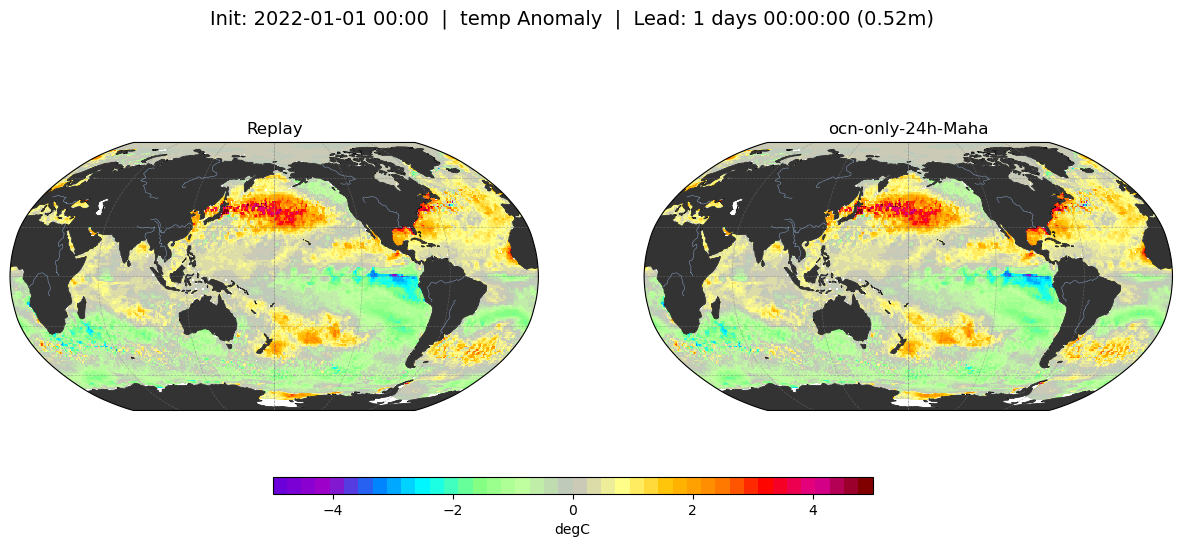

In [18]:
# ==========================================
# DATA PREPARATION
# ==========================================
# Construct common selection dictionary
sel_dict = {
    "time": plot_config["itime"],
    "lead_time": slice(plot_config["lead_start"], plot_config["lead_end"])
}

is_3d = var_config["vcoord"] in predictions[var_config["variable"]].coords
if is_3d:
    sel_dict[var_config["vcoord"]] = var_config["ivert"]

# Select Data
target = targets[var_config["variable"]].isel(sel_dict)
prediction = predictions[var_config["variable"]].isel(sel_dict)
init_time = predictions.time.isel(time=plot_config["itime"]).values

# Apply Masks
if plot_config["masked_array"]:
    mask = None
    if is_3d and var_config["vcoord"] == "z_l":
        mask_da = targets.so.isel({"time": plot_config["itime"], "z_l": var_config["ivert"]})
        mask = xr.where(mask_da == 0, 0, 1)
    elif var_config["variable"].lower() == "ssh":
        mask = 1 - np.isnan(ocn.SSH.isel(time=0))
    
    if mask is not None:
        target = target.where(mask)
        prediction = prediction.where(mask)

# Compute Anomaly
if plot_config["plot_anomaly"] and "climatology" in locals(): 
    if climatology.any():
        forecast_time = init_time + prediction["lead_time"]
    
        prediction = prediction.assign_coords(forecast_time=("lead_time", forecast_time.values))
        target = target.assign_coords(forecast_time=("lead_time", forecast_time.values))
    
        prediction = prediction.groupby("forecast_time.month") - climatology
        target = target.groupby("forecast_time.month") - climatology

# Extract Grid info
lons = prediction["lon"].values
lats = prediction["lat"].values
times = prediction["lead_time"]

# Extract Initialization String (Updated per request)
init_raw = init_time
# Handle cases where time is a 0-d array or scalar
if hasattr(init_raw, "item"):
    init_raw = init_raw.item()
init_str = pd.to_datetime(init_raw).strftime("%Y-%m-%d %H:%M")

# ==========================================
# PLOTTING & ANIMATION SETUP
# ==========================================

def plot_robinson_panel(ax, data, lons, lats, title, cmap, vmin, vmax):
    """Helper to plot data on a Robinson projection with cyclic wrapping."""
    ax.set_global()
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#333333', zorder=2) # Dark grey land
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, zorder=3)
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Add cyclic point to handle the 360->0 wrap seam
    data_c, lons_c = add_cyclic_point(data, coord=lons)
    
    # Create 2D mesh for contourf
    # Note: add_cyclic_point returns 1D coord, we need meshgrid for contourf
    lon2d_c, lat2d = np.meshgrid(lons_c, lats)

    # --- CHANGE TO PCOLORMESH ---
    mesh = ax.pcolormesh(
        lon2d_c, lat2d, data_c,
        transform=ccrs.PlateCarree(), 
        cmap=cmap, 
        vmin=vmin, 
        vmax=vmax, 
        shading='auto', # 'auto' or 'nearest' prevents interpolation
        zorder=1
    )
    
    ax.set_title(title, fontsize=12)
    return mesh

# Initialize Figure with Robinson Projection
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5),
                        subplot_kw={'projection': ccrs.Robinson(
                            central_longitude=plot_config["central_lon_init"]
                        )})

# Setup Colorbar
norm = Normalize(vmin=plot_config["vmin_cbar"], vmax=plot_config["vmax_cbar"])
sm = ScalarMappable(norm=norm, cmap=plot_config["cmap"])
sm.set_array([]) 

cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.03])  # left, bottom, width, height
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{var_config['units']}")
cbar.ax.tick_params(labelsize=10)

def update(frame):
    # Data snapshot
    data_target = target.isel(lead_time=frame).squeeze().values
    data_pred = prediction.isel(lead_time=frame).squeeze().values

    # Clear Axes
    axs[0].clear()
    axs[1].clear()

    # Draw panels
    plot_robinson_panel(
        axs[0], data_target, lons, lats, plot_config["truth"],
        plot_config["cmap"], plot_config["vmin_cbar"], plot_config["vmax_cbar"],
        
    )

    plot_robinson_panel(
        axs[1], data_pred, lons, lats, model_config["name"],
        plot_config["cmap"], plot_config["vmin_cbar"], plot_config["vmax_cbar"]
    )

    # Update Title
    leadtime = pd.to_timedelta(times[frame].values, unit="D")
    print(f"Processing frame {frame}: lead time = {leadtime}")

    var_name = var_config['variable']
    if plot_config["plot_anomaly"]:
        var_name += " Anomaly"
        
    # Format: Init | Variable | Lead Time | Depth (if 3D)
    main_title = f"Init: {init_str}  |  {var_name}  |  Lead: {leadtime}"
    
    if is_3d:
        d_val = prediction[var_config['vcoord']].values
        depth_str = f"{d_val.item():.2f}" if np.ndim(d_val)==0 else f"{d_val[0]:.2f}"
        main_title += f" ({depth_str}m)"
    
    plt.suptitle(main_title, fontsize=14, y=0.98)

    return []

# ==========================================
# EXECUTION
# ==========================================
ani = FuncAnimation(fig, update, frames=len(times), interval=500, blit=False)

# Construct Filename
f_type = "anomaly" if plot_config["plot_anomaly"] else "full"
if is_3d:
    d_val = prediction[var_config['vcoord']].values
    depth_str = f"{d_val.item():.2f}" if np.ndim(d_val)==0 else f"{d_val[0]:.2f}"
    fname_suffix = f"{var_config['vcoord']}-{depth_str}m_{model_config['name']}"
else:
    fname_suffix = f"{model_config['name']}_{model_config['run']}"

fname = f"{var_config['variable']}_{f_type}_{fname_suffix}_robinson.mp4"

if plot_config["save_plot"]:
    print(f"Saving animation to figures/{fname}...")
    ani.save(f"figures/{fname}", writer='ffmpeg', fps=8, dpi=200)
else:
    HTML(ani.to_jshtml())
    plt.show()